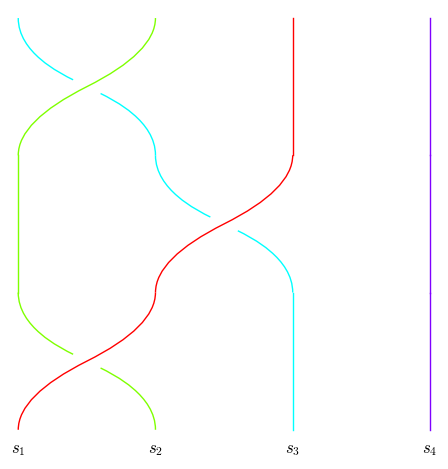

In [4]:
from sage.groups.braid import BraidGroup
B = BraidGroup(4)
b = B([1,2,1])

# Get the braid plot
p = b.plot(color='rainbow', axes=False)

# Number of strands
n = 4
# For 'bottom-top' orientation, strands start at y=0, x = 0,1,2,...,n-1
# Add labels at the bottom of each strand
for i in range(n):
    p += text(f'$s_{i+1}$', (i, -0.15), fontsize=12, color='black')

p.show(aspect_ratio=1, axes=False)

In [30]:
B = BraidGroup(4)
s0,s1,s2 = B.gens()
b = s0 * s1 * s0   # = s2 * s1 * s2

print(b.Tietze())

g2_inv_b = s1**-1 * b

#print(g2_inv_b)

#print(g2_inv_b.Tietze())   # should be (1, 2) — positive!
#print(g2_inv_b.is_positive())  # should be True
def reduced_word(braid):
    nf = braid.left_normal_form()
    print(nf)
    b=B.one()
    for factor in nf:
        #print(factor)
        b=b*factor
    return b

c=reduced_word(g2_inv_b)
print(c)
if min(c.Tietze())>0:
    d=s1*c
    print(d)
else:
    print("false")
#print(reduced_word(g2_inv_b))

(1, 2, 1)
(1, s0*s1)
s0*s1
s1*s0*s1


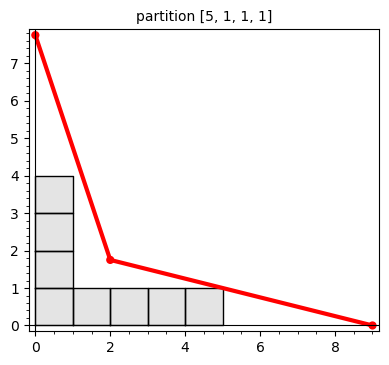


Partition [5, 1, 1, 1]:
P_0 = (0, 31/4)
P_1 = (2, 7/4)
P_2 = (9, 0)


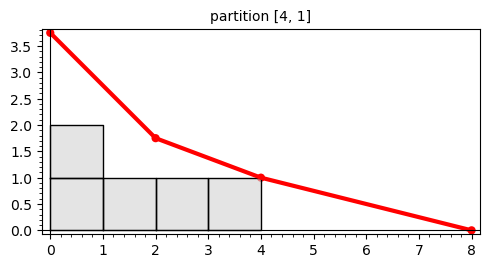


Partition [4, 1]:
P_0 = (0, 15/4)
P_1 = (2, 7/4)
P_2 = (4, 1)
P_3 = (8, 0)


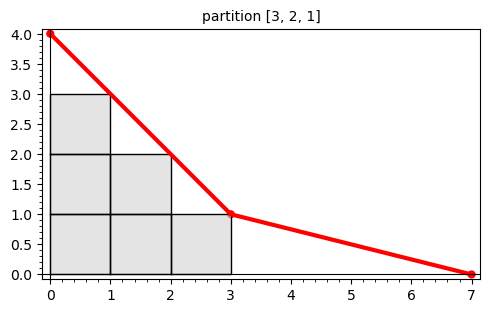


Partition [3, 2, 1]:
P_0 = (0, 4)
P_1 = (3, 1)
P_2 = (7, 0)


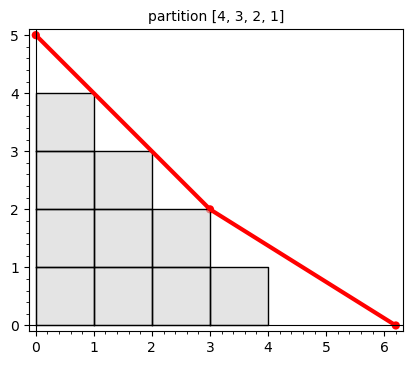


Partition [4, 3, 2, 1]:
P_0 = (0, 5)
P_1 = (3, 2)
P_2 = (31/5, 0)


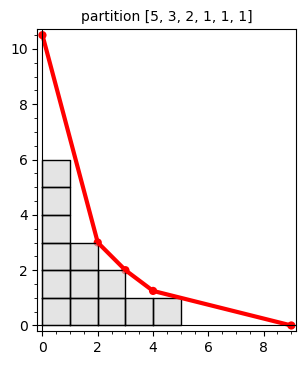


Partition [5, 3, 2, 1, 1, 1]:
P_0 = (0, 21/2)
P_1 = (2, 3)
P_2 = (3, 2)
P_3 = (4, 5/4)
P_4 = (9, 0)

Partition [2, 2] was rejected:
No concave-up polygonal curve found. The partition may not be concave.


In [37]:
from sage.all import QQ, Polyhedron, Graphics, polygon, line, point


# ------------------------------------------------------------
# Basic partition utilities
# ------------------------------------------------------------

def conjugate_partition(lam):
    """
    Return the column heights of the partition lam.

    Example:
        [4, 1, 1] -> [3, 1, 1, 1]
    """
    lam = list(lam)

    if len(lam) == 0:
        return []

    m = max(lam)
    return [sum(1 for r in lam if r >= j) for j in range(1, m + 1)]


def remove_collinear(points):
    """
    Remove intermediate points lying on the same line segment.
    """
    if len(points) <= 2:
        return points

    new_points = [points[0]]

    for i in range(1, len(points) - 1):
        x0, y0 = new_points[-1]
        x1, y1 = points[i]
        x2, y2 = points[i + 1]

        # Slopes P0P1 and P1P2 are equal iff this determinant vanishes.
        if (y1 - y0) * (x2 - x1) != (y2 - y1) * (x1 - x0):
            new_points.append(points[i])

    new_points.append(points[-1])
    return new_points


# ------------------------------------------------------------
# Main function
# ------------------------------------------------------------

def concave_curve_for_partition(lam, simplify=True, max_tries=60):
    """
    Given a concave partition lam, find points P_0,...,P_k such that:

      - P_0 lies on the vertical axis,
      - P_k lies on the horizontal axis,
      - the polygonal curve through the P_i is concave up,
      - the partition is exactly the set of boxes lying under the curve.

    Convention:
    We use French notation.

    If the column heights are c_0,...,c_{m-1}, then the condition that
    the boxes in column j fit completely under the curve is encoded by

        c_j <= f(j + 1) < c_j + 1.

    The use of j + 1 comes from checking the right edge of the box.
    """

    lam = list(lam)

    # Check that lam is actually a partition.
    if any(a < b for a, b in zip(lam, lam[1:])):
        raise ValueError("Input must be a partition: entries must be weakly decreasing.")

    if any(a < 0 for a in lam):
        raise ValueError("Partition parts must be nonnegative.")

    lam = [a for a in lam if a > 0]

    if len(lam) == 0:
        return [(QQ(0), QQ(0))]

    c = conjugate_partition(lam)
    m = len(c)

    # We solve for y_1,...,y_{m+1}.
    #
    # Points will be:
    #   P_0 = (0, y_0),
    #   P_1 = (1, y_1),
    #   ...
    #   P_{m+1} = (m+1, y_{m+1}).
    #
    # Then we may add one final point on the x-axis.
    n = m + 1

    lower = [QQ(h) for h in c] + [QQ(0)]

    for N in range(2, max_tries + 2):
        # Use QQ(1) / QQ(2**N), not QQ(1, 2**N).
        eps = QQ(1) / QQ(2**N)

        upper = [QQ(h + 1) - eps for h in c] + [QQ(1) - eps]

        ieqs = []

        # Bounds:
        # lower[i] <= y_i <= upper[i].
        for i in range(n):
            # y_i >= lower[i]
            row = [-lower[i]] + [QQ(0)] * n
            row[1 + i] = QQ(1)
            ieqs.append(row)

            # y_i <= upper[i]
            row = [upper[i]] + [QQ(0)] * n
            row[1 + i] = QQ(-1)
            ieqs.append(row)

        # Nonincreasing:
        # y_i - y_{i+1} >= 0.
        for i in range(n - 1):
            row = [QQ(0)] + [QQ(0)] * n
            row[1 + i] = QQ(1)
            row[1 + i + 1] = QQ(-1)
            ieqs.append(row)

        # Concave up:
        #
        # slope_i <= slope_{i+1}
        #
        # Since the x-spacing is 1, this means
        #
        # y_{i+1} - y_i <= y_{i+2} - y_{i+1},
        #
        # equivalently
        #
        # y_i - 2y_{i+1} + y_{i+2} >= 0.
        for i in range(n - 2):
            row = [QQ(0)] + [QQ(0)] * n
            row[1 + i] = QQ(1)
            row[1 + i + 1] = QQ(-2)
            row[1 + i + 2] = QQ(1)
            ieqs.append(row)

        P = Polyhedron(ieqs=ieqs, base_ring=QQ)

        if not P.is_empty():
            y = [QQ(v) for v in P.vertices_list()[0]]

            # Choose y_0 so that the first slope agrees with the second slope.
            # This automatically preserves concavity up at the beginning.
            if n >= 2:
                y0 = QQ(2) * y[0] - y[1]
            else:
                y0 = y[0]

            points = [(QQ(0), y0)]

            for i in range(n):
                points.append((QQ(i + 1), y[i]))

            # Add a final point on the horizontal axis if needed.
            if y[-1] != 0:
                last_slope = y[-1] - y[-2]

                if last_slope >= 0:
                    raise RuntimeError("Unexpected nonnegative final slope.")

                # Continue with the same slope until hitting the x-axis.
                x_last = QQ(m + 1)
                x_final = x_last - y[-1] / last_slope

                points.append((x_final, QQ(0)))

            if simplify:
                points = remove_collinear(points)

            return points

    raise ValueError("No concave-up polygonal curve found. The partition may not be concave.")


def print_points(points):
    """
    Print points as P_0, P_1, ...
    """
    for i, P in enumerate(points):
        print(f"P_{i} = {P}")


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

def partition_boxes(lam, color="lightgray"):
    """
    Draw the Young diagram in French notation.
    """
    G = Graphics()

    for row, length in enumerate(lam):
        for col in range(length):
            square = [
                (col, row),
                (col + 1, row),
                (col + 1, row + 1),
                (col, row + 1),
            ]

            G += polygon(square, fill=True, color=color, alpha=0.6)
            G += line(square + [square[0]], color="black")

    return G


def plot_concave_partition(lam, title=None, show_points=True):
    """
    Plot the partition together with the concave-up polygonal curve.
    """
    pts = concave_curve_for_partition(lam)

    G = partition_boxes(lam)
    G += line(pts, color="red", thickness=3)

    if show_points:
        G += point(pts, color="red", size=35)

    if title is None:
        title = f"partition {lam}"

    G.show(
        aspect_ratio=1,
        axes=True,
        frame=True,
        title=title,
        figsize=5,
    )

    return pts


# ------------------------------------------------------------
# Examples
# ------------------------------------------------------------

examples = [
    [5, 1, 1, 1],      # hook
    [4, 1],            # small hook
    [3, 2, 1],         # staircase
    [4, 3, 2, 1],      # larger staircase
    [5,3,2,1,1,1]
]

for lam in examples:
    pts = plot_concave_partition(lam)
    print(f"\nPartition {lam}:")
    print_points(pts)


# ------------------------------------------------------------
# Non-concave example
# ------------------------------------------------------------

try:
    plot_concave_partition([2, 2])
except ValueError as e:
    print("\nPartition [2, 2] was rejected:")
    print(e)

In [ ]:
# ============================================================
#  Concave partitions — convex hull of qualifying outside boxes
#
#  French notation, rows are parts:
#    lam = [lam_1 >= lam_2 >= ...], lam_i = length of row i from bottom.
#    Box (c, r) has bottom-left corner at (c-1, r-1).
#    Box (c, r) is in lam  iff  1 <= c <= lam[r-1].
#
#  Qualifying boxes: c >= 2, r >= 2, outside lam, 8-neighbour-free from lam.
#
#  The convex hull of the qualifying region is unbounded (+inf in x and y).
#  Its boundary has two infinite rays:
#    - upward    from the leftmost  finite vertex
#    - rightward from the rightmost finite vertex
#
#  Concavity: lam is concave iff the hull does not touch lam at all
#             (corners count as touching).
#
#  Sage inequality convention: Polyhedron stores [b, a0, a1] meaning
#    a0*x + a1*y + b >= 0, so the outward normal is (-a0, -a1).
#  A lower-left-facing facet has outward normal pointing SW, i.e. a0 > 0, a1 > 0.
# ============================================================

from sage.geometry.polyhedron.constructor import Polyhedron


# ── helpers ─────────────────────────────────────────────────

def _row_len(lam, r):
    r = int(r)
    if 1 <= r <= len(lam):
        return int(lam[r - 1])
    return 0

def _in_lam(lam, c, r):
    c, r = int(c), int(r)
    if not (1 <= r <= len(lam)):
        return False
    return 1 <= c <= int(lam[r - 1])

def _touches8(lam, c, r):
    c, r = int(c), int(r)
    for dc in [-1, 0, 1]:
        for dr in [-1, 0, 1]:
            if dc == 0 and dr == 0:
                continue
            if _in_lam(lam, c + dc, r + dr):
                return True
    return False

def _qualifying_boxes(lam):
    max_col = int(max(lam)) + 3
    max_row = int(len(lam)) + 3
    result = []
    for c in range(2, max_col + 1):
        for r in range(2, max_row + 1):
            if not _in_lam(lam, c, r) and not _touches8(lam, c, r):
                result.append((c, r))
    result.sort()
    return result

def _finite_vertices(lam):
    """
    Return (finite_verts, ll_ieqs) for the unbounded convex hull.

    Sage inequality [b, a0, a1] means a0*x + a1*y + b >= 0.
    Outward normal of the feasible region is (-a0, -a1).
    Lower-left-facing facet (outward normal points SW): a0 > 0 and a1 > 0.

    ll_ieqs entries are (a0, a1, b) with a0*x + a1*y + b >= 0, a0 > 0, a1 > 0.
    """
    cands = _qualifying_boxes(lam)
    if not cands:
        return [], []

    ll_corners = list(set((c - 1, r - 1) for c, r in cands))
    P = Polyhedron(vertices=ll_corners)

    ll_ieqs = []
    for ieq in P.inequalities():
        b  = QQ(ieq[0])
        a0 = QQ(ieq[1])
        a1 = QQ(ieq[2])
        if a0 > 0 and a1 > 0:          # <-- lower-left-facing: outward normal (-a0,-a1) is SW
            ll_ieqs.append((a0, a1, b))

    finite_verts = set()
    for v in P.vertices():
        x = QQ(v[0])
        y = QQ(v[1])
        for (a0, a1, b) in ll_ieqs:
            if a0 * x + a1 * y + b == 0:
                finite_verts.add((x, y))
                break

    finite_verts = sorted((ZZ(x), ZZ(y)) for x, y in finite_verts)
    return finite_verts, ll_ieqs

def _in_hull(ll_ieqs, x, y):
    """
    True iff (x, y) is in the unbounded hull (boundary included).
    The unbounded hull satisfies exactly the lower-left-facing constraints.
    """
    x, y = QQ(x), QQ(y)
    for (a0, a1, b) in ll_ieqs:
        if a0 * x + a1 * y + b < 0:
            return False
    return True


# ── main function ────────────────────────────────────────────

def concave_hull(lam):
    """
    Check whether lam is concave and print the finite vertices of the
    unbounded convex hull of the qualifying outside boxes.
    Returns the vertex list, or None if not concave.
    """
    if not lam:
        print("Empty partition.")
        return []

    finite_verts, ll_ieqs = _finite_vertices(lam)

    if not finite_verts:
        print("{} : no qualifying boxes found.".format(list(lam)))
        return []

    lam_boxes = []
    for r in range(1, len(lam) + 1):
        for c in range(1, _row_len(lam, r) + 1):
            lam_boxes.append((c, r))

    for (c, r) in lam_boxes:
        test_pts = [
            (c - 1, r - 1),
            (c,     r - 1),
            (c,     r    ),
            (c - 1, r    ),
            (QQ(2*c - 1) / 2, QQ(2*r - 1) / 2),
        ]
        for pt in test_pts:
            if _in_hull(ll_ieqs, pt[0], pt[1]):
                print("{} is not concave!  (box ({},{}) touches the hull at {})".format(
                    list(lam), c, r, pt))
                return None

    print("Partition {} is concave.".format(list(lam)))
    print("Finite vertices of the unbounded convex hull: {}".format(finite_verts))
    return finite_verts


# ── plotting ─────────────────────────────────────────────────

def plot_partition(lam, size=1):
    """
    Plot the Young diagram, qualifying boxes, unbounded convex hull
    (shaded with rays), and finite vertices.  Returns a Graphics object.
    """
    S = size

    finite_verts, ll_ieqs = _finite_vertices(lam)
    cands     = _qualifying_boxes(lam)
    lam_boxes = []
    for r in range(1, len(lam) + 1):
        for c in range(1, _row_len(lam, r) + 1):
            lam_boxes.append((c, r))

    not_concave = False
    if finite_verts and ll_ieqs:
        for (c, r) in lam_boxes:
            test_pts = [
                (c - 1, r - 1),
                (c,     r - 1),
                (c,     r    ),
                (c - 1, r    ),
                (QQ(2*c - 1) / 2, QQ(2*r - 1) / 2),
            ]
            if any(_in_hull(ll_ieqs, p[0], p[1]) for p in test_pts):
                not_concave = True
                break

    lam_fill = '#F7C1C1' if not_concave else '#B5D4F4'
    lam_edge = '#E24B4A' if not_concave else '#378ADD'
    h_fill   = '#FCEBEB' if not_concave else '#EEEDFE'
    h_edge   = '#A32D2D' if not_concave else '#534AB7'
    v_col    = '#A32D2D' if not_concave else '#534AB7'

    G = Graphics()

    # hull shaded region and boundary rays
    if finite_verts:
        large = (max(int(max(lam)), int(len(lam))) + 5) * S
        v = finite_verts
        poly_pts = [(0, int(v[0][1]) * S)]
        for (x, y) in v:
            poly_pts.append((int(x) * S, int(y) * S))
        poly_pts += [(int(v[-1][0]) * S, 0), (large, 0),
                     (large, large), (0, large)]
        G += polygon2d(poly_pts, color=h_fill, alpha=0.5, zorder=1)

        bdy_pts = [(0, int(v[0][1]) * S)]
        for (x, y) in v:
            bdy_pts.append((int(x) * S, int(y) * S))
        bdy_pts.append((int(v[-1][0]) * S, 0))
        G += line(bdy_pts, color=h_edge, thickness=1.8, zorder=4)

    # qualifying boxes
    for (c, r) in cands:
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color='#F1EFE8', edgecolor='#B4B2A9', thickness=0.5, zorder=2
        )

    # lambda boxes
    for (c, r) in lam_boxes:
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color=lam_fill, edgecolor=lam_edge, thickness=0.8, zorder=3
        )

    # finite vertices
    for (x, y) in finite_verts:
        xi, yi = int(x), int(y)
        G += point((xi*S, yi*S), color=v_col, size=30, zorder=6)
        G += text(
            '({},{})'.format(xi, yi),
            (xi*S + 0.15*S, yi*S + 0.15*S),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='left'
        )

    # title
    title = 'lam = {}'.format(tuple(lam))
    if not_concave:
        title += '  -- not concave!'
    top_y = (max(int(len(lam)),
                 int(finite_verts[-1][1]) if finite_verts else 0) + 1) * S
    G += text(title, (0, top_y + 0.3*S),
              fontsize=10, color='black', zorder=7,
              horizontal_alignment='left')

    G.axes(True)
    G.set_aspect_ratio(1)
    return G


def plot_all(lams=None, ncols=2, figsize=(14, 18)):
    """
    Plot a list of partitions in a grid.  Defaults to six built-in examples.
    """
    if lams is None:
        lams = [[4,3,2,1], [4,4,4,4], [5], [5,3,2], [3,1], [3,3,1]]
    nrows = ceil(len(lams) / ncols)
    plots = [plot_partition(lam) for lam in lams]
    G = graphics_array(plots, nrows, ncols)
    G.show(figsize=figsize)


# ── run ──────────────────────────────────────────────────────

lams=[[4,3,2,1], [4,4,4,4], [5], [5,3,2], [3,1], [3,3,1], [7,5,3,2,1,1,1]]

for lam in lams:
    concave_hull(lam)

plot_all(lams)

